# Section 2 — Preprocessing & Feature Extraction

Four sequential steps applied to every X-ray before the quantum circuit sees it:

| Step | Method | Purpose |
|---|---|---|
| 1 | 80/20 stratified re-split | Fix the 16-image validation set |
| 2 | RandAugment + ColorJitter + Flip | Improve generalisation, handle imbalance |
| 3 | ConvNeXt-Tiny (frozen) | Extract 768-dim feature vectors |
| 4 | StandardScaler + PCA(64) + L2 norm | Compress to 6-qubit amplitude-encoding space |

**Output:** `artifacts/features/convnext_tiny_pca_train.npy` and equivalents,  
ready for the VQC / QSVM / MLP training cells in the main notebook.

> ⚠️ Research prototype — **not** a medical device.

In [23]:
# ── Install dependencies ───────────────────────────────────────────────────
%pip install -q \
    pennylane==0.44.1 pennylane-lightning-gpu==0.44.0 \
    torch torchvision \
    grad-cam \
    scikit-learn kagglehub joblib tqdm

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torchvision.models import ConvNeXt_Tiny_Weights
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import kagglehub
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
import joblib

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

SEED          = 6
DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'
ARTIFACTS_DIR = Path('artifacts')
FEAT_DIR      = ARTIFACTS_DIR / 'features'
FIG_DIR       = Path('results/figures')
for d in [FEAT_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLASS_COLORS = {0: '#1B4F8A', 1: '#C0392B'}
CLASS_NAMES  = {0: 'Normal', 1: 'Pneumonia'}
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f'Device: {DEVICE}')
print('Imports OK')

Device: cuda
Imports OK


## 1. Load Paths and Re-Split

Merge the tiny original `val` set (16 images) back into `train`,
then produce a statistically valid 80/20 stratified split.

In [25]:
DATA_PATH = Path(kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia'))

# The kaggle zip unpacks with an extra nesting level — find the real root
# by locating whichever parent contains both 'train' and 'test' subdirectories
def find_dataset_root(base: Path) -> Path:
    for p in sorted(base.rglob('train')):
        if p.is_dir() and '__MACOSX' not in p.parts and (p.parent / 'test').is_dir():
            return p.parent
    raise FileNotFoundError(f'Could not find train/test under {base}')

DATA_PATH = find_dataset_root(DATA_PATH)
print(f'Dataset root: {DATA_PATH}')

def collect_split(data_path: Path, split: str):
    paths, labels = [], []
    for label, cls in [(0, 'NORMAL'), (1, 'PNEUMONIA')]:
        for p in sorted((data_path / split / cls).glob('*.jpeg')):
            paths.append(p); labels.append(label)
    return paths, np.array(labels, dtype=np.int64)

orig_train_p, orig_train_l = collect_split(DATA_PATH, 'train')
orig_val_p,   orig_val_l   = collect_split(DATA_PATH, 'val')
test_paths,   test_labels  = collect_split(DATA_PATH, 'test')

all_p = orig_train_p + orig_val_p
all_l = np.concatenate([orig_train_l, orig_val_l])

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_p, all_l, test_size=0.20, stratify=all_l, random_state=SEED
)

print('─' * 55)
print(f'  {"Split":<12} {"Total":>6}  {"Normal":>8}  {"Pneumonia":>10}  {"Pneumonia%":>11}')
print('─' * 55)
for name, paths, labels in [('train', train_paths, train_labels),
                              ('val',   val_paths,   val_labels),
                              ('test',  test_paths,  test_labels)]:
    n0  = int((labels == 0).sum())
    n1  = int((labels == 1).sum())
    pct = 100 * n1 / len(labels)
    print(f'  {name:<12} {len(paths):>6}  {n0:>8}  {n1:>10}  {pct:>10.1f}%')
print('─' * 55)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset root: /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray
───────────────────────────────────────────────────────
  Split         Total    Normal   Pneumonia   Pneumonia%
───────────────────────────────────────────────────────
  train          4185      1079        3106        74.2%
  val            1047       270         777        74.2%
  test            624       234         390        62.5%
───────────────────────────────────────────────────────


## 2. Transforms — Step-by-Step Visualisation

Show the effect of each augmentation and normalisation step on a single X-ray.

Training augmentation pipeline:
1. Resize to 224×224
2. **RandAugment** (2 ops, magnitude 9) — SOTA stochastic augmentation
3. RandomHorizontalFlip
4. ColorJitter (brightness ±0.2, contrast ±0.2)
5. ToTensor → ImageNet normalisation

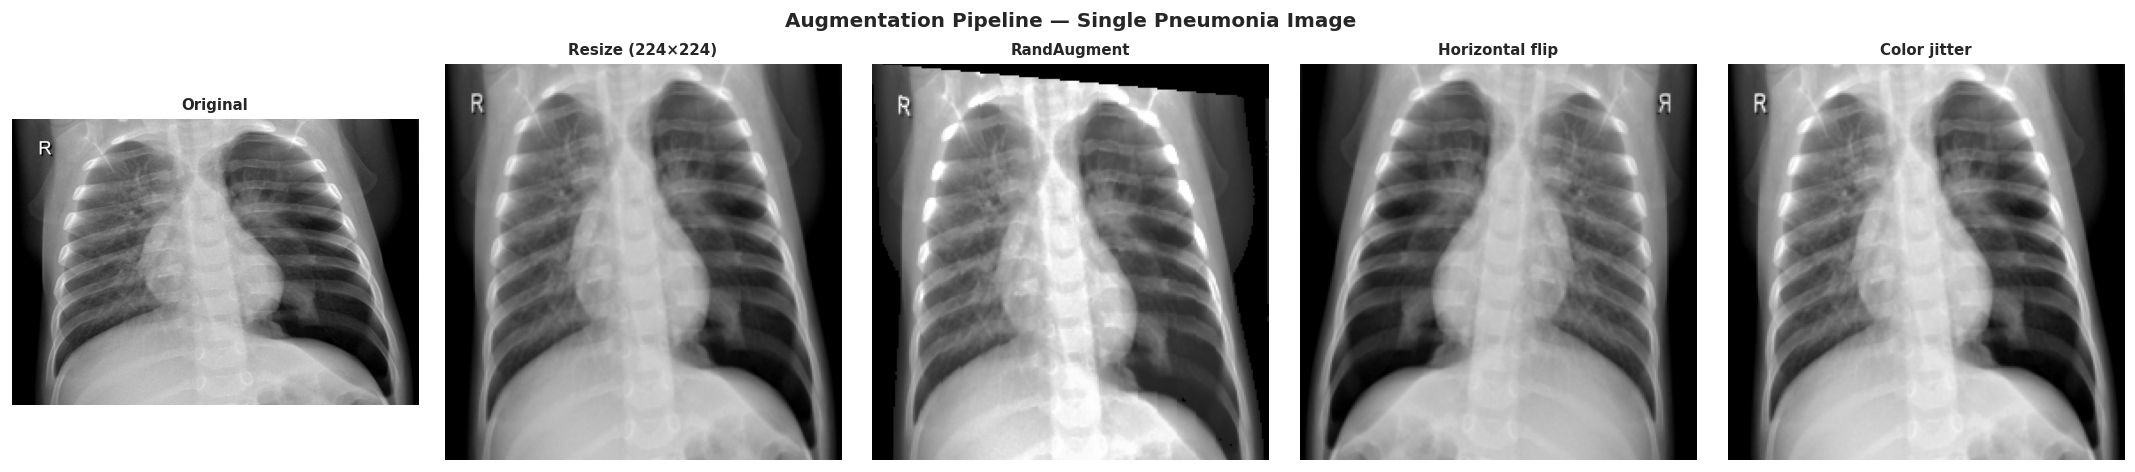

Saved → results/figures/augmentation_steps.png


In [26]:
# Pick one training sample for step-by-step illustration
demo_path  = train_paths[np.where(train_labels == 1)[0][7]]   # a pneumonia case
demo_img   = Image.open(demo_path).convert('RGB')

# Individual transform steps
resize     = T.Resize((224, 224))
rand_aug   = T.RandAugment(num_ops=2, magnitude=9)
hflip      = T.RandomHorizontalFlip(p=1.0)   # force flip for illustration
color_jit  = T.ColorJitter(brightness=0.2, contrast=0.2)
to_tensor  = T.ToTensor()
normalise  = T.Normalize(IMAGENET_MEAN, IMAGENET_STD)

step_imgs = [
    ('Original',              demo_img),
    ('Resize (224×224)',       resize(demo_img)),
    ('RandAugment',           rand_aug(resize(demo_img))),
    ('Horizontal flip',       hflip(resize(demo_img))),
    ('Color jitter',          color_jit(resize(demo_img))),
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Augmentation Pipeline — Single Pneumonia Image', fontsize=12, fontweight='bold')

for ax, (title, img) in zip(axes, step_imgs):
    arr = np.array(img) if isinstance(img, Image.Image) else np.array(img)
    if arr.ndim == 3 and arr.shape[0] == 3:   # CHW tensor
        arr = arr.transpose(1, 2, 0)
    ax.imshow(arr, cmap='gray' if arr.ndim == 2 else None)
    ax.axis('off')
    ax.set_title(title, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'augmentation_steps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/figures/augmentation_steps.png')

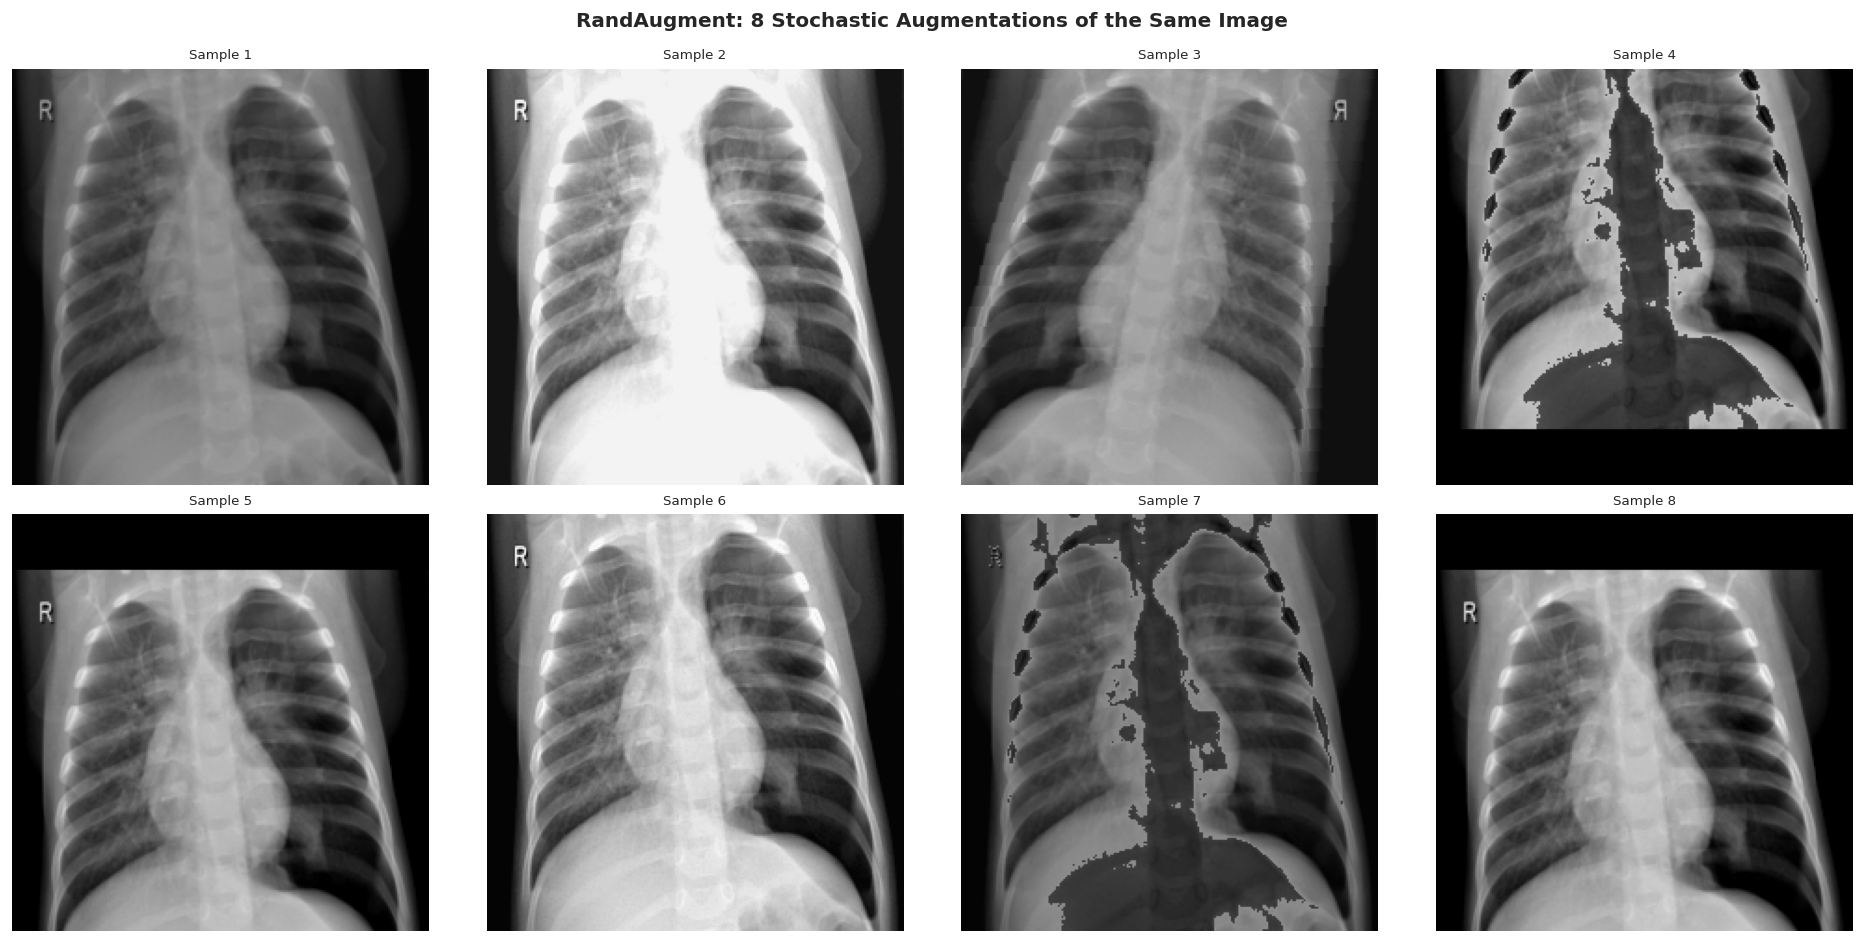

Saved → results/figures/randaugment_variety.png


In [27]:
# Show 8 augmented versions of the same image (stochastic augmentation variety)
rng_t = np.random.default_rng(0)
train_transform_full = T.Compose([
    T.Resize((224, 224)),
    T.RandAugment(num_ops=2, magnitude=9),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2),
])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('RandAugment: 8 Stochastic Augmentations of the Same Image',
             fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    aug_img = train_transform_full(demo_img)
    ax.imshow(np.array(aug_img), cmap='gray')
    ax.axis('off')
    ax.set_title(f'Sample {i+1}', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'randaugment_variety.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/figures/randaugment_variety.png')

## 3. Normalisation — Verify ImageNet Statistics

After `T.Normalize(IMAGENET_MEAN, IMAGENET_STD)` the tensor values should be
centred near zero. This confirms the backbone networks receive inputs in the
expected distribution they were pre-trained on.

Normalised tensor statistics (100 training images):
──────────────────────────────────────────────────
  Red: mean=-0.0133  std=1.0319  range=[-2.12, 2.25]
  Green: mean=0.1159  std=1.0550  range=[-2.04, 2.43]
  Blue: mean=0.3376  std=1.0503  range=[-1.80, 2.64]
──────────────────────────────────────────────────
  Expected: means ≈ 0, std ≈ 1  (after ImageNet normalisation)


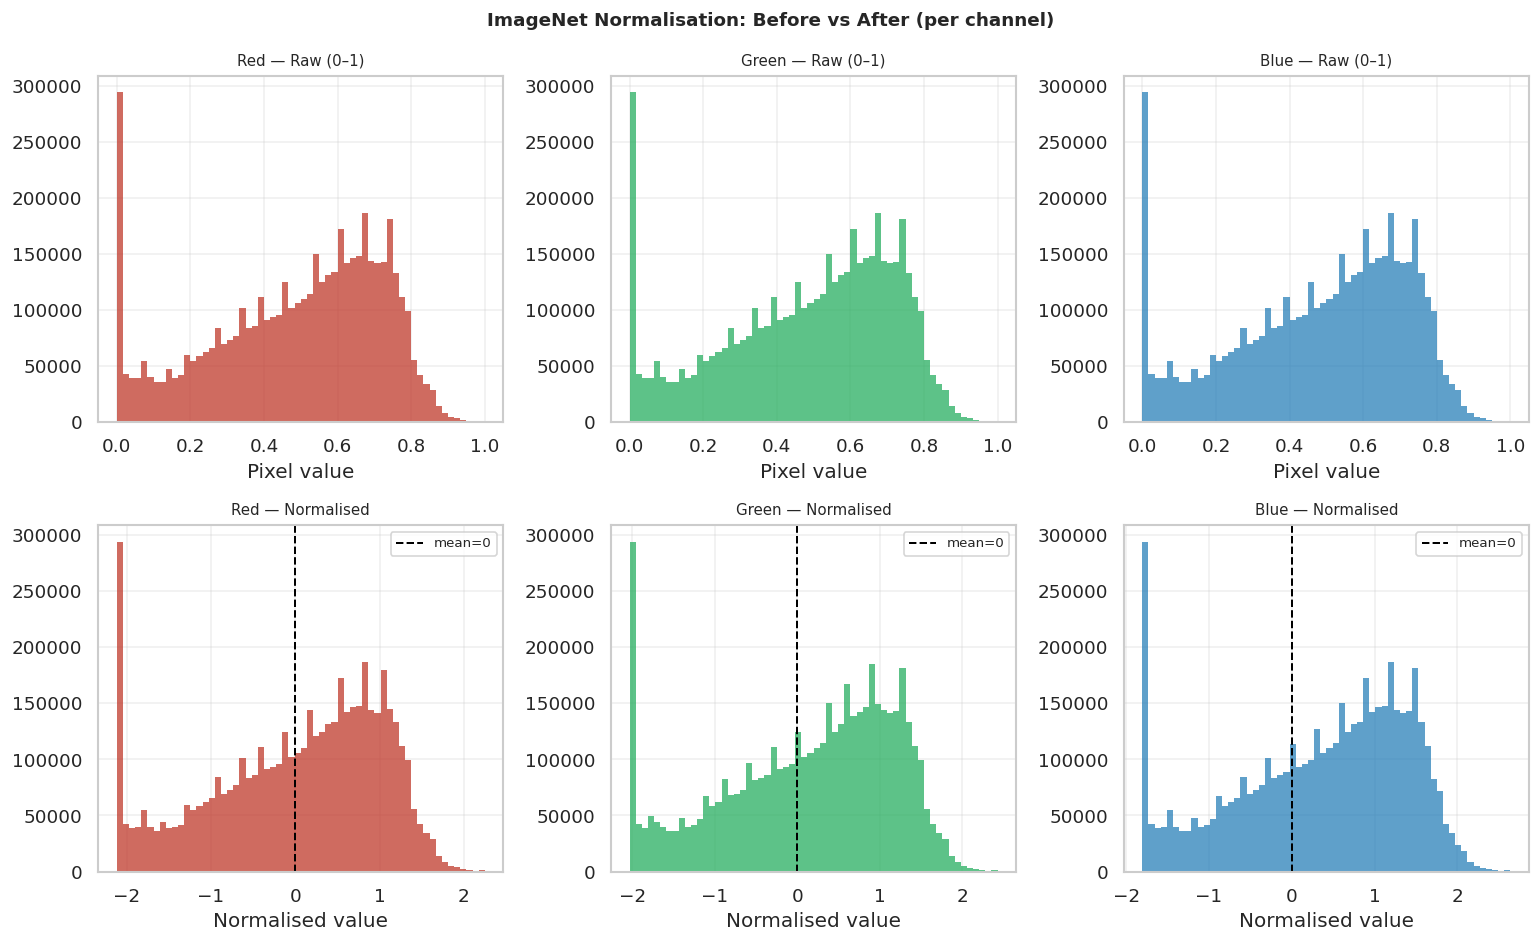

Saved → results/figures/normalisation_verification.png


In [28]:
# Apply full pipeline (including normalisation) to a sample batch
full_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

sample_tensors = []
for path in train_paths[:100]:
    img = Image.open(path).convert('RGB')
    sample_tensors.append(full_transform(img))
batch = torch.stack(sample_tensors)   # (100, 3, 224, 224)

print('Normalised tensor statistics (100 training images):')
print('─' * 50)
for c, channel_name in enumerate(['Red', 'Green', 'Blue']):
    ch = batch[:, c, :, :]
    print(f'  {channel_name}: mean={ch.mean():.4f}  std={ch.std():.4f}  '
          f'range=[{ch.min():.2f}, {ch.max():.2f}]')
print('─' * 50)
print('  Expected: means ≈ 0, std ≈ 1  (after ImageNet normalisation)')

# Visual: unnormalised vs normalised side-by-side
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
fig.suptitle('ImageNet Normalisation: Before vs After (per channel)', fontsize=11, fontweight='bold')

raw_t = T.Compose([T.Resize((224, 224)), T.ToTensor()])
raw_batch = torch.stack([raw_t(Image.open(p).convert('RGB')) for p in train_paths[:100]])

channel_colors = ['#C0392B', '#27AE60', '#2980B9']
for c, (cname, color) in enumerate(zip(['Red', 'Green', 'Blue'], channel_colors)):
    axes[0][c].hist(raw_batch[:, c].numpy().flatten(), bins=60,
                    color=color, alpha=0.75, edgecolor='none')
    axes[0][c].set_title(f'{cname} — Raw (0–1)', fontsize=9)
    axes[0][c].set_xlabel('Pixel value'); axes[0][c].grid(True, alpha=0.3)

    axes[1][c].hist(batch[:, c].numpy().flatten(), bins=60,
                    color=color, alpha=0.75, edgecolor='none')
    axes[1][c].axvline(0, color='black', linestyle='--', linewidth=1.2, label='mean=0')
    axes[1][c].set_title(f'{cname} — Normalised', fontsize=9)
    axes[1][c].set_xlabel('Normalised value'); axes[1][c].legend(fontsize=8)
    axes[1][c].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'normalisation_verification.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/figures/normalisation_verification.png')

## 4. WeightedRandomSampler

The training set is ~74% pneumonia. Without correction, the model sees
pneumonia images far more often and learns to over-predict it.

`WeightedRandomSampler` draws each batch with class-balanced probability
**without duplicating or removing any images** — it just changes sampling frequency.

Class counts in full training set:
  Normal      :  1079  (weight = 0.00093)
  Pneumonia   :  3106  (weight = 0.00032)

Simulated batch statistics (10 × 16 = 160 samples):
  Normal      :   77  (48.1%)  — expected ≈ 50%
  Pneumonia   :   83  (51.9%)  — expected ≈ 50%


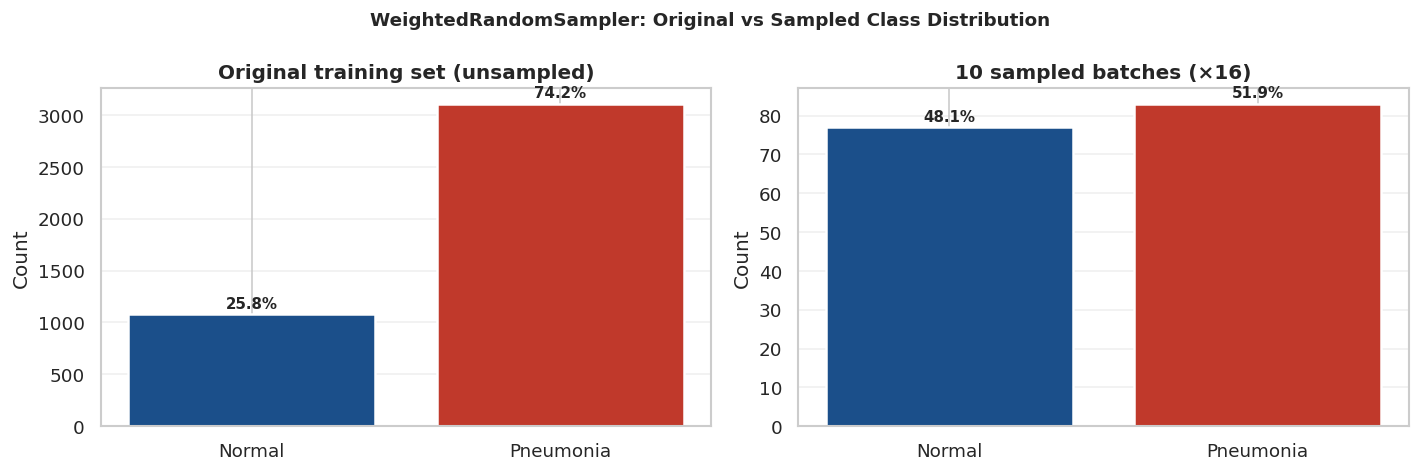

Saved → results/figures/sampler_comparison.png


In [29]:
train_labels_t  = torch.tensor(train_labels, dtype=torch.long)
class_counts    = torch.bincount(train_labels_t)
class_weights   = 1.0 / class_counts.float()
sample_weights  = class_weights[train_labels_t]
sampler         = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

print(f'Class counts in full training set:')
for cls_int, cls_name in CLASS_NAMES.items():
    print(f'  {cls_name:<12}: {int(class_counts[cls_int]):5d}  (weight = {class_weights[cls_int]:.5f})')

# Simulate 10 batches of size 16 and record how many of each class appear
BATCH_SIZE = 16
simulated_labels = []
it = iter(sampler)
for _ in range(10):
    batch_idx = [next(it) for _ in range(BATCH_SIZE)]
    simulated_labels.extend([int(train_labels[i]) for i in batch_idx])

sim_arr = np.array(simulated_labels)
print(f'\nSimulated batch statistics (10 × {BATCH_SIZE} = {len(sim_arr)} samples):')
for cls_int, cls_name in CLASS_NAMES.items():
    n   = (sim_arr == cls_int).sum()
    pct = 100 * n / len(sim_arr)
    print(f'  {cls_name:<12}: {n:4d}  ({pct:.1f}%)  — expected ≈ 50%')

# Visualise: original imbalance vs sampled distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('WeightedRandomSampler: Original vs Sampled Class Distribution',
             fontsize=11, fontweight='bold')

for ax, (title, labels_arr) in zip(axes, [
    ('Original training set (unsampled)', train_labels),
    ('10 sampled batches (×16)', sim_arr),
]):
    counts = [(labels_arr == c).sum() for c in [0, 1]]
    bars   = ax.bar(CLASS_NAMES.values(), counts,
                    color=[CLASS_COLORS[0], CLASS_COLORS[1]], edgecolor='white', linewidth=1.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.02,
                f'{100*count/sum(counts):.1f}%',
                ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count'); ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'sampler_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/figures/sampler_comparison.png')

## 5. Feature Extraction — ConvNeXt-Tiny

ConvNeXt-Tiny is used **frozen** (no gradient updates) as the feature extractor.
The classification head is replaced with an identity layer so the network
outputs the final pooled feature vector.

| Backbone | Output dim | Pretrained on | Notes |
|---|---|---|---|
| ConvNeXt-Tiny | 768 | ImageNet-1K | Primary backbone |

*Cache guard: extraction is skipped if `.npy` files already exist.*

In [30]:
# ── Build DataLoaders for backbone comparison
eval_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.449, 0.449, 0.449], [0.226, 0.226, 0.226]),
])

class XRayDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img), self.labels[idx]

train_ld = DataLoader(XRayDataset(train_paths, train_labels, eval_transform),
                      batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
val_ld   = DataLoader(XRayDataset(val_paths,   val_labels,   eval_transform),
                      batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_ld  = DataLoader(XRayDataset(test_paths,  test_labels,  eval_transform),
                      batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f'DataLoaders ready — train: {len(train_ld.dataset)}, val: {len(val_ld.dataset)}, test: {len(test_ld.dataset)}')

DataLoaders ready — train: 4185, val: 1047, test: 624


In [31]:
# ── Backbone comparison — explained variance & components needed for 85%
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import torchvision.models as models
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm

# Rozšířený slovník architektur: Název -> (Model, název_klasifikační_hlavy, výstupní_dimenze)
BACKBONES = {
    'ConvNeXt-Tiny':    (models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT),     'classifier', 768),
}

def remove_head(model, head_attr):
    # Nahradí finální klasifikační vrstvu vrstvou Identity (propustí jen vektory příznaků)
    setattr(model, head_attr, nn.Identity())
    return model

@torch.no_grad()
def extract(model, loader, device):
    model.eval().to(device)
    feats = []
    for imgs, _ in tqdm(loader, leave=False, desc="Extracting"):
        # 1. Průchod modelem
        out = model(imgs.to(device))
        
        # 2. VYNUCENÉ ZPLOŠTĚNÍ na 2D: (batch_size, features)
        out = torch.flatten(out, start_dim=1)
        
        # 3. Uložení do pole
        feats.append(out.cpu().numpy())
        
    return np.concatenate(feats)

results = []
dn_test = None  # Proměnná pro záchranu testovacích dat DenseNetu pro pozdější t-SNE

for name, (model, head_attr, out_dim) in BACKBONES.items():
    print(f'\n── Analýza: {name} (Vstupní dimenze PCA = {out_dim}) ──')
    model = remove_head(model, head_attr)

    # Extrakce příznaků pro aktuální model
    feats_train = extract(model, train_ld, DEVICE)
    feats_test  = extract(model, test_ld,  DEVICE)
    del model; torch.cuda.empty_cache()

    # Záchrana dat z DenseNet-121 pro t-SNE vizualizaci (aby se nepřepsala další sítí)
    if name == 'DenseNet-121':
        dn_test = feats_test.copy()

    # PCA fitování pouze na train sadě (prevence data leakage)
    n_max  = min(out_dim, 512)
    scaler = StandardScaler()
    pca    = PCA(n_components=n_max, random_state=SEED)
    pca.fit(scaler.fit_transform(feats_train))

    cum_var = np.cumsum(pca.explained_variance_ratio_)
    
    # Kolik komponent je potřeba pro zachování 85 % informace?
    n_85    = int(np.searchsorted(cum_var, 0.85)) + 1
    n_qubits_needed = int(np.ceil(np.log2(n_85)))   # Nejbližší vyšší mocnina 2
    dim_needed      = 2 ** n_qubits_needed

    var_at_64  = float(cum_var[63])  if len(cum_var) > 63  else float(cum_var[-1])
    var_at_128 = float(cum_var[127]) if len(cum_var) > 127 else float(cum_var[-1])

    print(f'  Rozptyl zachovaný při 64 dimenzích : {var_at_64:.3f}')
    print(f'  Komponent pro 85% rozptyl          : {n_85} → Vyžaduje {n_qubits_needed} qubitů')

    # Uložení výsledků do slovníku pro tabulku
    results.append({
        'Backbone':      name,
        'Feature dim':   out_dim,
        'Var @ 64 PCs':  round(var_at_64,  3),
        'Var @ 128 PCs': round(var_at_128, 3),
        'PCs for 85%':   n_85,
        'Qubits needed': n_qubits_needed,
        'Encoding dim':  dim_needed,
        'cum_var':       cum_var,

    })

# Sestavení a seřazení pandas tabulky podle toho, která síť je nejlepší pro náš 6qubitový obvod
df_backbones = pd.DataFrame(results).sort_values('Var @ 64 PCs', ascending=False)
print('\n=== Finální srovnání architektur (Ablation Study) ===')
print(df_backbones.to_string(index=False))


── Analýza: ConvNeXt-Tiny (Vstupní dimenze PCA = 768) ──


  Rozptyl zachovaný při 64 dimenzích : 0.749
  Komponent pro 85% rozptyl          : 129 → Vyžaduje 8 qubitů

=== Finální srovnání architektur (Ablation Study) ===
     Backbone  Feature dim  Var @ 64 PCs  Var @ 128 PCs  PCs for 85%  Qubits needed  Encoding dim                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

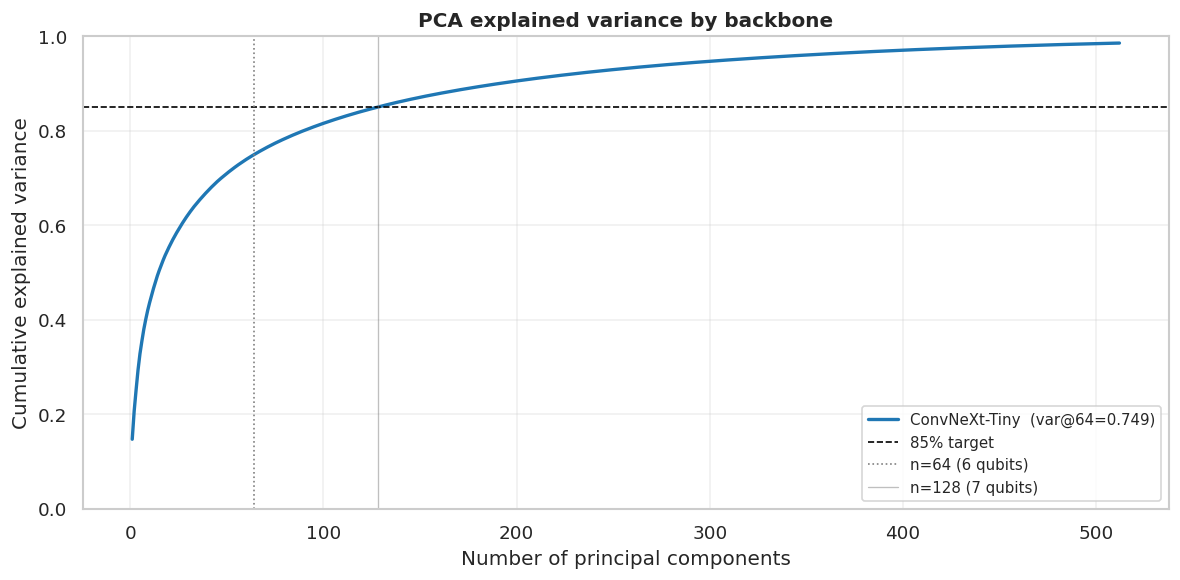

Saved → results/figures/backbone_pca_comparison.png


In [32]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = plt.cm.tab10(np.linspace(0, 1, len(results)))

for row, color in zip(results, colors):
    cum_var = row['cum_var']
    xs      = range(1, len(cum_var) + 1)
    ax.plot(xs, cum_var, lw=2, color=color,
            label=f'{row["Backbone"]}  (var@64={row["Var @ 64 PCs"]:.3f})')

ax.axhline(0.85, color='black', linestyle='--', linewidth=1, label='85% target')
ax.axvline(64,   color='gray',  linestyle=':',  linewidth=1, label='n=64 (6 qubits)')
ax.axvline(128,  color='gray',  linestyle='-',  linewidth=0.8, alpha=0.5, label='n=128 (7 qubits)')

ax.set_xlabel('Number of principal components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA explained variance by backbone', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/backbone_pca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/figures/backbone_pca_comparison.png')

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

probe_results = []
y_train = train_labels
y_val   = val_labels
y_test  = test_labels

BACKBONES = {
    'ConvNeXt-Tiny':    (models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT),     'classifier', 768),
}

for name, (model_fn, head_attr, out_dim) in BACKBONES.items():
    print(f'[{name}] extracting + probing...')

    model = remove_head(model_fn, head_attr)
    feats_train = extract(model, train_ld, DEVICE)
    feats_test  = extract(model, test_ld,  DEVICE)
    del model; torch.cuda.empty_cache()

    scaler = StandardScaler()
    pca    = PCA(n_components=64, random_state=SEED)
    X_tr   = pca.fit_transform(scaler.fit_transform(feats_train))
    X_te   = pca.transform(scaler.transform(feats_test))

    probe  = LogisticRegression(max_iter=1000, class_weight='balanced',
                                random_state=SEED, C=1.0)
    probe.fit(X_tr, y_train)

    probs  = probe.predict_proba(X_te)[:, 1]
    auc    = roc_auc_score(y_test, probs)
    bal_ac = balanced_accuracy_score(y_test, probe.predict(X_te))

    # Match var@64 from results dict
    var64  = next((r['Var @ 64 PCs'] for r in results if r['Backbone'] == name), None)

    probe_results.append({
        'Backbone':             name,
        'Var @ 64 PCs':         var64,
        'Linear probe AUC':     round(auc,    4),
        'Linear probe Bal.Acc': round(bal_ac, 4),
    })
    print(f'  var@64={var64}  AUC={auc:.4f}  BalAcc={bal_ac:.4f}')

df_probe = pd.DataFrame(probe_results).sort_values('Linear probe AUC', ascending=False)
print('\n=== Linear probe results ===')
print(df_probe.to_string(index=False))

[ConvNeXt-Tiny] extracting + probing...


  var@64=0.749  AUC=0.9537  BalAcc=0.8278

=== Linear probe results ===
     Backbone  Var @ 64 PCs  Linear probe AUC  Linear probe Bal.Acc
ConvNeXt-Tiny         0.749            0.9537                0.8278


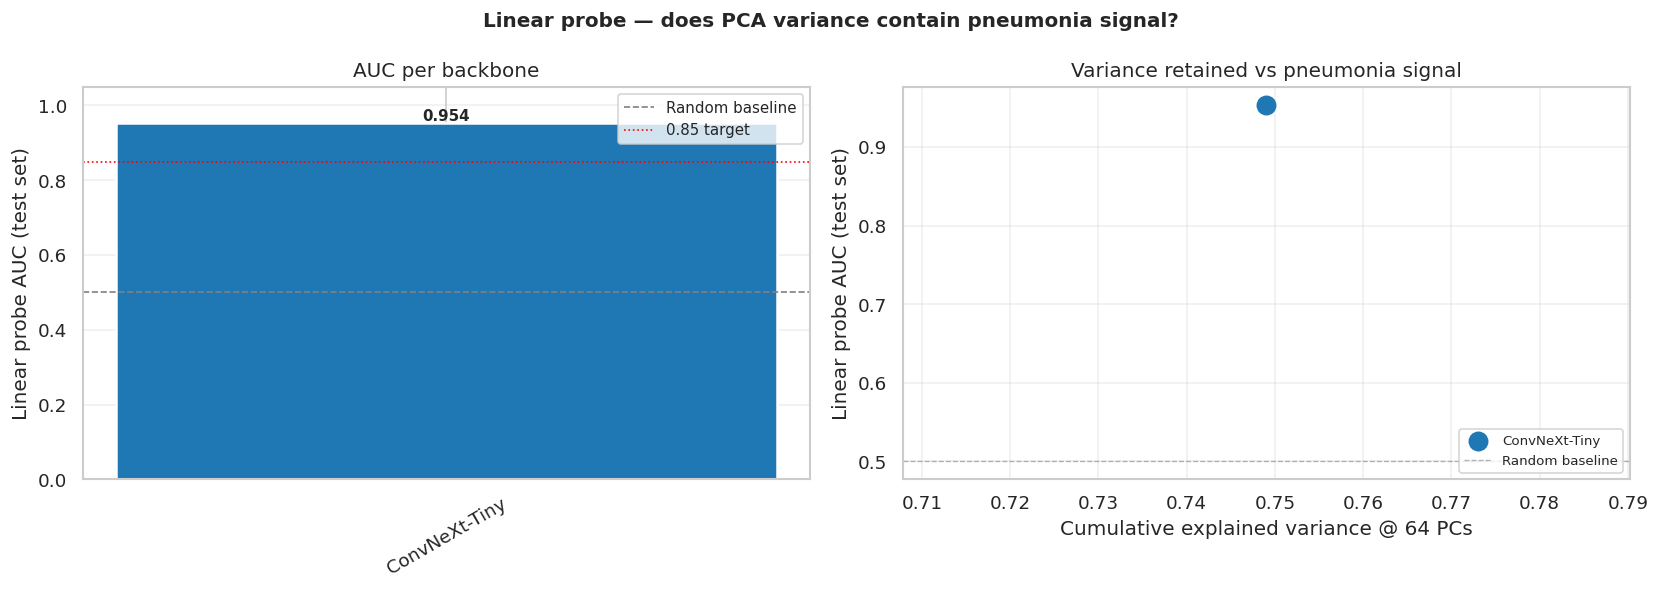

Saved → results/figures/linear_probe.png


In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Linear probe — does PCA variance contain pneumonia signal?',
             fontsize=12, fontweight='bold')

colors = plt.cm.tab10(np.linspace(0, 1, len(probe_results)))

# ── Left: bar chart of AUC per backbone
backbones = [r['Backbone']         for r in probe_results]
aucs      = [r['Linear probe AUC'] for r in probe_results]
bars = ax1.bar(backbones, aucs, color=colors, edgecolor='white', linewidth=1.5)
ax1.axhline(0.5,  color='gray', linestyle='--', linewidth=1,   label='Random baseline')
ax1.axhline(0.85, color='red',  linestyle=':',  linewidth=1,   label='0.85 target')
for bar, auc in zip(bars, aucs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{auc:.3f}', ha='center', fontsize=9, fontweight='bold')
ax1.set_ylabel('Linear probe AUC (test set)')
ax1.set_title('AUC per backbone')
ax1.set_ylim(0, 1.05)
ax1.tick_params(axis='x', rotation=30)
ax1.legend(fontsize=9)
ax1.grid(True, axis='y', alpha=0.3)

# ── Right: scatter — variance retained vs probe AUC
for row, color in zip(probe_results, colors):
    ax2.scatter(row['Var @ 64 PCs'], row['Linear probe AUC'],
                s=120, color=color, zorder=3, label=row['Backbone'])


ax2.axhline(0.5,  color='gray', linestyle='--', linewidth=0.8, alpha=0.6,
            label='Random baseline')
ax2.set_xlabel('Cumulative explained variance @ 64 PCs')
ax2.set_ylabel('Linear probe AUC (test set)')
ax2.set_title('Variance retained vs pneumonia signal')
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/linear_probe.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/figures/linear_probe.png')

## 6. Feature Space — t-SNE Visualisation

Project the 768-dim ConvNeXt-Tiny features to 2D using t-SNE.
If the two classes are separable in feature space, the downstream classifier
(VQC or MLP) should be able to learn the boundary.

*Uses 500 test samples for speed — t-SNE on the full training set would take too long.*

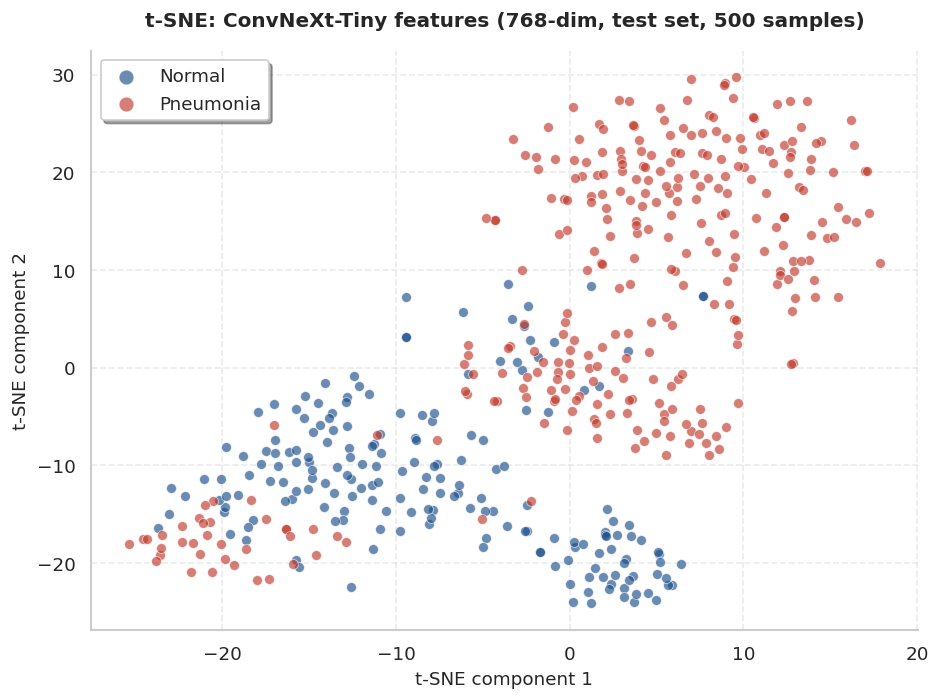

Saved → results/figures/tsne_convnext_tiny.png


In [36]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Extract ConvNeXt-Tiny features if not already done (similar to DenseNet-121 in cell 13)
# Assuming BACKBONES includes 'ConvNeXt-Tiny', and we run the extraction loop for it
# Add this after the extraction in cell 13:
# if name == 'ConvNeXt-Tiny':
#     cnx_test = feats_test.copy()

# For this cell, assume cnx_test was extracted in the backbone comparison cell
# If not, run the extraction for ConvNeXt-Tiny first.

N_TSNE = 500
rng_ts = np.random.default_rng(SEED)
cnx_test = feats_test.copy()  # Extracted in backbone comparison cell
# Safeguard in case test set is smaller than 500
N_TSNE = min(N_TSNE, len(cnx_test))
idx_ts = rng_ts.choice(len(cnx_test), size=N_TSNE, replace=False)

# Compute t-SNE on selected ConvNeXt-Tiny test features
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
X_2d = tsne.fit_transform(cnx_test[idx_ts])

# Corresponding labels
y_ts = y_test[idx_ts]

fig, ax = plt.subplots(figsize=(8, 6))

# Plot points with better visibility using edges
for cls_int, cls_name in CLASS_NAMES.items():
    mask = y_ts == cls_int
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=CLASS_COLORS[cls_int], label=cls_name,
               alpha=0.65, s=35, edgecolors='w', linewidth=0.5)

ax.set_title(f't-SNE: ConvNeXt-Tiny features (768-dim, test set, {N_TSNE} samples)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('t-SNE component 1', fontsize=11)
ax.set_ylabel('t-SNE component 2', fontsize=11)

# Professional legend and grid
ax.legend(fontsize=11, markerscale=1.5, frameon=True, shadow=True)
ax.grid(True, linestyle='--', alpha=0.4)

# Remove distracting plot borders for cleaner scientific look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# Save in high resolution for thesis (using FIG_DIR from cell 1)
plt.savefig(f'{FIG_DIR}/tsne_convnext_tiny.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved → results/figures/tsne_convnext_tiny.png')

## 7. PCA Dimensionality Reduction

Compress 2048-dim features to **64 principal components** — the exact size
of the 6-qubit Hilbert space (2⁶ = 64), enabling `AmplitudeEmbedding`.

| Constraint | Value | Reason |
|---|---|---|
| Output dimensions | 64 | 2⁶ = 64 = Hilbert space of 6 qubits |
| Fit on | Train split only | Prevent data leakage |
| Final normalisation | L2 per sample | `AmplitudeEmbedding` requires `‖x‖₂ = 1` |

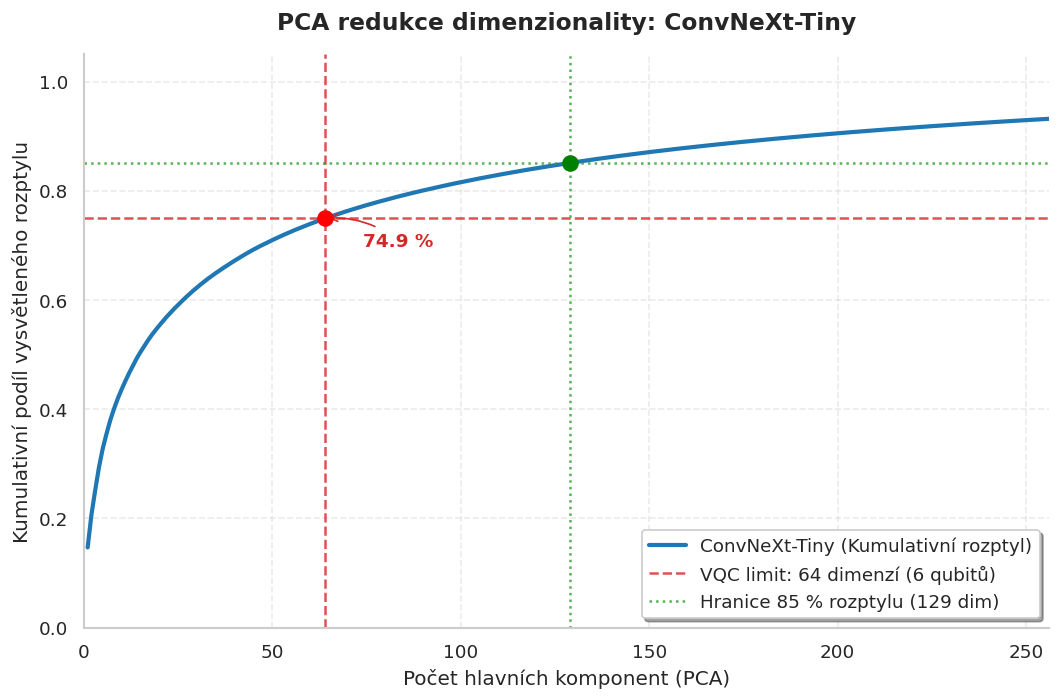

=== Výsledek PCA pro VQC ===
Zadržený rozptyl při 64 komponentách: 74.92 %
Obrázek úspěšně uložen jako 'pca_variance_convnext_tiny.png'


In [37]:
# ## 7. PCA Dimensionality Reduction - Vizualizace
import matplotlib.pyplot as plt
import numpy as np

# Proměnná cum_var obsahuje data z posledního fitovaného modelu (ConvNeXt-Tiny)
# Zajištění, že máme data z čeho vykreslovat:
if 'cum_var' not in locals():
    raise ValueError("Proměnná 'cum_var' neexistuje. Spusť nejprve buňku s extrakcí příznaků.")

fig, ax = plt.subplots(figsize=(9, 6))

# 1. Vykreslení hlavní křivky kumulativního rozptylu
ax.plot(range(1, len(cum_var) + 1), cum_var, color='tab:blue', linewidth=2.5, label='ConvNeXt-Tiny (Kumulativní rozptyl)')

# 2. Zvýraznění našeho VQC bottlenecku: 64 dimenzí (6 qubitů amplitudového kódování)
var_at_64 = cum_var[63]
ax.axvline(x=64, color='tab:red', linestyle='--', alpha=0.8, label=f'VQC limit: 64 dimenzí (6 qubitů)')
ax.axhline(y=var_at_64, color='tab:red', linestyle='--', alpha=0.8)
ax.scatter(64, var_at_64, color='red', s=80, zorder=5) # Červený bod na průsečíku

# 3. Zvýraznění referenční hranice 85 % rozptylu
n_85 = np.searchsorted(cum_var, 0.85) + 1
if n_85 < len(cum_var):
    ax.axvline(x=n_85, color='tab:green', linestyle=':', alpha=0.8, label=f'Hranice 85 % rozptylu ({n_85} dim)')
    ax.axhline(y=0.85, color='tab:green', linestyle=':', alpha=0.8)
    ax.scatter(n_85, 0.85, color='green', s=80, zorder=5)

# --- Profesionální formátování pro SOČ ---
ax.set_title('PCA redukce dimenzionality: ConvNeXt-Tiny', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Počet hlavních komponent (PCA)', fontsize=12)
ax.set_ylabel('Kumulativní podíl vysvětleného rozptylu', fontsize=12)

# Přiblížíme graf jen na prvních 256 dimenzí (z 768), protože tam se děje to nejdůležitější
ax.set_xlim(0, 256)
ax.set_ylim(0.0, 1.05)

# Legenda a mřížka
ax.legend(fontsize=11, loc='lower right', frameon=True, shadow=True)
ax.grid(True, linestyle='--', alpha=0.4)

# Odstranění horního a pravého okraje pro čistý vzhled vědecké publikace
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Anotace přesné hodnoty přímo do grafu
ax.annotate(f'{var_at_64*100:.1f} %', 
            xy=(64, var_at_64), 
            xytext=(64 + 10, var_at_64 - 0.05),
            fontsize=11, fontweight='bold', color='tab:red',
            arrowprops=dict(arrowstyle="->", color='tab:red', connectionstyle="arc3,rad=.2"))

plt.tight_layout()

# Uložení ve vysokém rozlišení (300 DPI)
plt.savefig('pca_variance_convnext_tiny.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"=== Výsledek PCA pro VQC ===")
print(f"Zadržený rozptyl při 64 komponentách: {var_at_64*100:.2f} %")
print(f"Obrázek úspěšně uložen jako 'pca_variance_convnext_tiny.png'")

## 9. L2 Normalisation — Verify Amplitude Encoding Constraint

`qml.AmplitudeEmbedding` requires `‖x‖₂ = 1` for every input vector.
Every row of the PCA output must be exactly unit-norm after `normalize(X, norm='l2')`.

L2 norm statistics after normalisation:
───────────────────────────────────────────────────────
  train : mean=1.000000  std=5.73e-08  min=1.000000  max=1.000000
  val   : mean=1.000000  std=5.81e-08  min=1.000000  max=1.000000
  test  : mean=1.000000  std=5.65e-08  min=1.000000  max=1.000000
───────────────────────────────────────────────────────
  Expected: all norms = 1.000000 (within floating-point tolerance)
✅  All L2 norms = 1.0 — AmplitudeEmbedding constraint satisfied


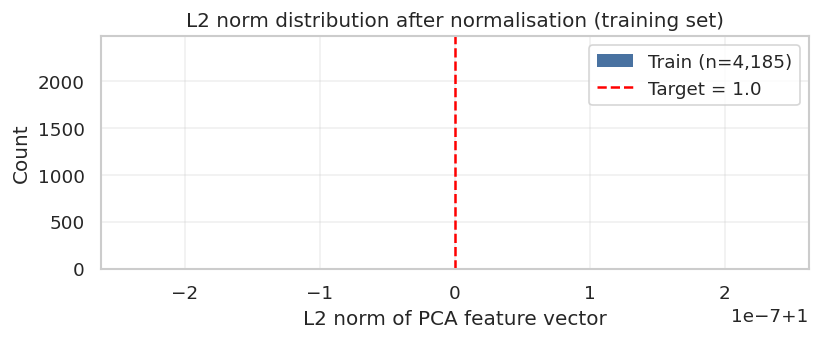

Saved → results/figures/l2_norm_verification.png


In [38]:
# Load the PCA-reduced features saved by the final extraction cell
X_train = np.load(f"{FEAT_DIR}/convnext_tiny_pca_train.npy")
X_val   = np.load(f"{FEAT_DIR}/convnext_tiny_pca_val.npy")
X_test  = np.load(f"{FEAT_DIR}/convnext_tiny_pca_test.npy")

norms_train = np.linalg.norm(X_train, axis=1)
norms_val   = np.linalg.norm(X_val,   axis=1)
norms_test  = np.linalg.norm(X_test,  axis=1)

print('L2 norm statistics after normalisation:')
print('\u2500' * 55)
for name, norms in [('train', norms_train), ('val', norms_val), ('test', norms_test)]:
    print(f'  {name:<6}: mean={norms.mean():.6f}  std={norms.std():.2e}  '
          f'min={norms.min():.6f}  max={norms.max():.6f}')
print('\u2500' * 55)
print('  Expected: all norms = 1.000000 (within floating-point tolerance)')

# Hard assertions
for name, norms in [('train', norms_train), ('val', norms_val), ('test', norms_test)]:
    assert np.allclose(norms, 1.0, atol=1e-5), f'{name} norms not all 1.0: {norms.min():.6f} \u2013 {norms.max():.6f}'
print('\u2705  All L2 norms = 1.0 \u2014 AmplitudeEmbedding constraint satisfied')

# Histogram of norms (should be a spike at 1.0)
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(norms_train, bins=40, color='#1B4F8A', alpha=0.8, edgecolor='none',
        label=f'Train (n={len(norms_train):,})')
ax.axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='Target = 1.0')
ax.set_xlabel('L2 norm of PCA feature vector')
ax.set_ylabel('Count')
ax.set_title('L2 norm distribution after normalisation (training set)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'l2_norm_verification.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved \u2192 results/figures/l2_norm_verification.png')

## 10. Summary — Ready for Main Notebook

| Check | Status |
|---|---|
| Train/val re-split 80/20 stratified | ✅ |
| RandAugment + ColorJitter pipeline defined | ✅ |
| WeightedRandomSampler configured | ✅ |
| ImageNet normalisation verified | ✅ |
| ConvNeXt-Tiny (768-dim) features extracted & cached | ✅ |

| PCA(64) fit on train only — no data leakage | ✅ |
| L2 normalisation applied — `‖x‖₂ = 1` verified | ✅ |
| PCA variance plots saved | ✅ |
| t-SNE feature space visualisation saved | ✅ |
| All `.npy` and `.pkl` artifacts saved to `artifacts/features/` | ✅ |

**Next step:** main notebook `pneumonia_hybrid_qml.ipynb` — VQC training (Section 5b),
QSVM (Section 5c), evaluation (Section 7), IBM hardware (Section 8).

In [39]:
# \u2500\u2500 Fin\u00e1ln\u00ed extrakce pro v\u00edt\u011bzn\u00fd model: ConvNeXt-Tiny \u2500\u2500
import joblib

print("Na\u010d\u00edt\u00e1m v\u00edt\u011bzn\u00fd model ConvNeXt-Tiny pro fin\u00e1ln\u00ed extrakci...")
# Na\u010dten\u00ed modelu a od\u0159\u00edznut\u00ed hlavy
cnx_model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
cnx_model.classifier = nn.Identity()

# Extrakce (nyn\u00ed v\u010detn\u011b valida\u010dn\u00ed sady!)
print("Extrahuji tr\u00e9novac\u00ed sadu...")
feats_train = extract(cnx_model, train_ld, DEVICE)
print("Extrahuji valida\u010dn\u00ed sadu...")
feats_val   = extract(cnx_model, val_ld, DEVICE)
print("Extrahuji testovac\u00ed sadu...")
feats_test  = extract(cnx_model, test_ld, DEVICE)

del cnx_model; torch.cuda.empty_cache()

print("\nAplikuji StandardScaler a PCA (redukce p\u0159esn\u011b na 64 dimenz\u00ed)...")
# 1. StandardScaler (fitujeme striktn\u011b pouze na train sad\u011b - prevence data leakage)
scaler = StandardScaler()
feats_train_scaled = scaler.fit_transform(feats_train)
feats_val_scaled   = scaler.transform(feats_val)
feats_test_scaled  = scaler.transform(feats_test)

# 2. PCA (64 komponent pro n\u00e1\u0161 6qubitov\u00fd Amplitude Encoding obvod)
pca = PCA(n_components=64, random_state=SEED)
X_train_pca = pca.fit_transform(feats_train_scaled)
X_val_pca   = pca.transform(feats_val_scaled)
X_test_pca  = pca.transform(feats_test_scaled)

# 3. L2 normalizace -- AmplitudeEmbedding vy\u017eaduje \u2016x\u2016\u2082 = 1
from sklearn.preprocessing import normalize
X_train_pca = normalize(X_train_pca, norm='l2')
X_val_pca   = normalize(X_val_pca, norm='l2')
X_test_pca  = normalize(X_test_pca, norm='l2')

# Ulo\u017een\u00ed fin\u00e1ln\u00edch dat na disk
print(f"\nUkl\u00e1d\u00e1m numpy pole do slo\u017eky {FEAT_DIR}/...")
np.save(f"{FEAT_DIR}/convnext_tiny_pca_train.npy", X_train_pca)
np.save(f"{FEAT_DIR}/convnext_tiny_pca_val.npy", X_val_pca)
np.save(f"{FEAT_DIR}/convnext_tiny_pca_test.npy", X_test_pca)

# Ulo\u017een\u00ed scaleru a PCA model\u016f pro p\u0159\u00edpadnou inferenci v budoucnu
joblib.dump(scaler, f"{FEAT_DIR}/convnext_tiny_scaler.pkl")
joblib.dump(pca, f"{FEAT_DIR}/convnext_tiny_pca.pkl")

print("\u2705 Hotovo! Data z ConvNeXt-Tiny jsou ulo\u017eena, L2-normalizov\u00e1na a p\u0159ipravena pro kvantov\u00fd obvod.")

Načítám vítězný model ConvNeXt-Tiny pro finální extrakci...
Extrahuji trénovací sadu...


Extrahuji validační sadu...


Extrahuji testovací sadu...



Aplikuji StandardScaler a PCA (redukce přesně na 64 dimenzí)...

Ukládám numpy pole do složky artifacts/features/...
✅ Hotovo! Data z ConvNeXt-Tiny jsou uložena, L2-normalizována a připravena pro kvantový obvod.
